#### **Vietnam Bank Customer Churn Anslysis and Prediction**

# Setup & Configuration

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
from sqlalchemy import create_engine
from sklearn.preprocessing import StandardScaler

In [2]:
# Koneksi ke MySQL
engine = create_engine('mysql+pymysql://root:@localhost:3306/bank_churn_db')
df = pd.read_sql('SELECT * FROM v_churn_analytics', engine)
print(f"Data Berhasil Diambil: {df.shape[0]} baris")
df.head()

Data Berhasil Diambil: 49567 baris


,id,age,gender,occupation,customer_segment,loyalty_level,balance_income_ratio,tenure_age_ratio,risk_score,risk_segment,engagement_score,nums_service,digital_behavior,recency_days,credit_score,balance,monthly_income,active_member,is_churn
0,1,55,male,Chủ Doanh nghiệp nhỏ,Priority,Bronze,1.4653,0.0000,0.0359,Low,90.0,8,mobile,90,725,177306004.0,121000000.0,1,0
1,2,45,male,Nội trợ/Sinh viên,Mass,Gold,0.3855,0.0667,0.2664,Low,63.0,2,mobile,49,689,1927416.0,5000000.0,1,0
2,3,44,female,Chủ Doanh nghiệp nhỏ,Priority,Silver,2.7975,0.0909,0.1343,Low,36.0,8,offline,1391,702,304931745.0,109000000.0,0,0
3,4,44,male,Chủ Doanh nghiệp nhỏ,Priority,Bronze,0.6407,0.0682,0.2185,Low,23.0,3,offline,120,766,50615501.0,79000000.0,0,0
4,5,77,female,Giáo viên/Giảng viên,Emerging,Bronze,1.6213,0.0260,0.2942,Low,23.0,3,offline,1061,677,40532432.0,25000000.0,0,0


In [3]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 49567 entries, 0 to 49566
Data columns (total 19 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   id                    49567 non-null  int64  
 1   age                   49567 non-null  int64  
 2   gender                49567 non-null  object 
 3   occupation            49567 non-null  object 
 4   customer_segment      49567 non-null  object 
 5   loyalty_level         49567 non-null  object 
 6   balance_income_ratio  49567 non-null  float64
 7   tenure_age_ratio      49567 non-null  float64
 8   risk_score            49567 non-null  float64
 9   risk_segment          49567 non-null  object 
 10  engagement_score      49567 non-null  float64
 11  nums_service          49567 non-null  int64  
 12  digital_behavior      49567 non-null  object 
 13  recency_days          49567 non-null  int64  
 14  credit_score          49567 non-null  int64  
 15  balance            

In [4]:
df['occupation'].value_counts()

occupation
Kỹ sư/Chuyên viên IT             5140
Nội trợ/Sinh viên                5055
Quản lý/Lãnh đạo                 4981
Chủ Doanh nghiệp nhỏ             4945
Nhân viên văn phòng/Công chức    4922
Hưu trí                          4921
Kế toán/Tài chính                4921
Lao động phổ thông               4912
Kinh doanh/Bán hàng              4907
Giáo viên/Giảng viên             4863
Name: count, dtype: int64

In [5]:
occupation_map = {
    'Kỹ sư/Chuyên viên IT': 'IT Engineer/Specialist',
    'Nội trợ/Sinh viên': 'Homemaker/Student',
    'Quản lý/Lãnh đạo': 'Manager/Leader',
    'Chủ Doanh nghiệp nhỏ': 'Small Business Owner',
    'Nhân viên văn phòng/Công chức': 'Office Worker/Civil Servant',
    'Hưu trí': 'Retired',
    'Kế toán/Tài chính': 'Accountant/Finance',
    'Lao động phổ thông': 'Manual Laborer',
    'Kinh doanh/Bán hàng': 'Sales/Business',
    'Giáo viên/Giảng viên': 'Teacher/Lecturer'
}

# Replace occupation
df['occupation'] = df['occupation'].str.strip().map(occupation_map)

print("Distribusi Occupation Setelah Translasi:")
print(df['occupation'].value_counts())

# Cek hasil mapping
if df['occupation'].isnull().any():
    print("\n Warning: Ada beberapa baris yang tidak ter-map. Cek typo pada data ori.")

Distribusi Occupation Setelah Translasi:
occupation
IT Engineer/Specialist         5140
Homemaker/Student              5055
Manager/Leader                 4981
Small Business Owner           4945
Office Worker/Civil Servant    4922
Retired                        4921
Accountant/Finance             4921
Manual Laborer                 4912
Sales/Business                 4907
Teacher/Lecturer               4863
Name: count, dtype: int64


In [6]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 49567 entries, 0 to 49566
Data columns (total 19 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   id                    49567 non-null  int64  
 1   age                   49567 non-null  int64  
 2   gender                49567 non-null  object 
 3   occupation            49567 non-null  object 
 4   customer_segment      49567 non-null  object 
 5   loyalty_level         49567 non-null  object 
 6   balance_income_ratio  49567 non-null  float64
 7   tenure_age_ratio      49567 non-null  float64
 8   risk_score            49567 non-null  float64
 9   risk_segment          49567 non-null  object 
 10  engagement_score      49567 non-null  float64
 11  nums_service          49567 non-null  int64  
 12  digital_behavior      49567 non-null  object 
 13  recency_days          49567 non-null  int64  
 14  credit_score          49567 non-null  int64  
 15  balance            

In [7]:
df.describe()

,id,age,balance_income_ratio,tenure_age_ratio,risk_score,engagement_score,nums_service,recency_days,credit_score,balance,monthly_income,active_member,is_churn
count,49567.000000,49567.000000,49567.000000,49567.000000,49567.000000,49567.000000,49567.000000,49567.000000,49567.00000,4.956700e+04,4.956700e+04,49567.000000,49567.000000
mean,33273.476769,49.403373,1.606905,0.039480,0.269045,31.657312,3.568927,412.273347,684.61091,6.134760e+07,3.795570e+07,0.212763,0.179353
std,22563.877112,15.051397,1.308695,0.032989,0.091677,23.375193,2.001131,362.036230,51.17699,8.864224e+07,3.670388e+07,0.409265,0.383652
min,1.000000,20.000000,0.068100,0.000000,0.019700,7.000000,1.000000,1.000000,498.00000,4.086630e+05,3.000000e+06,0.000000,0.000000
25%,13565.500000,38.000000,0.772600,0.014900,0.200400,16.000000,2.000000,112.000000,649.00000,1.467906e+07,1.400000e+07,0.000000,0.000000
50%,30158.000000,47.000000,1.246300,0.035100,0.276800,22.000000,3.000000,310.000000,683.00000,3.089865e+07,2.300000e+07,0.000000,0.000000
75%,51312.000000,58.000000,2.014000,0.060000,0.338500,38.000000,5.000000,629.000000,718.00000,6.981742e+07,4.700000e+07,0.000000,0.000000
max,80000.000000,90.000000,26.686500,0.200000,0.540400,100.000000,8.000000,1628.000000,800.00000,1.000000e+09,2.080000e+08,1.000000,1.000000


# EDA

### Univariate Analysis

C:\Users\HP\AppData\Local\Temp\ipykernel_17332\350778146.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df, x='is_churn', palette='viridis')


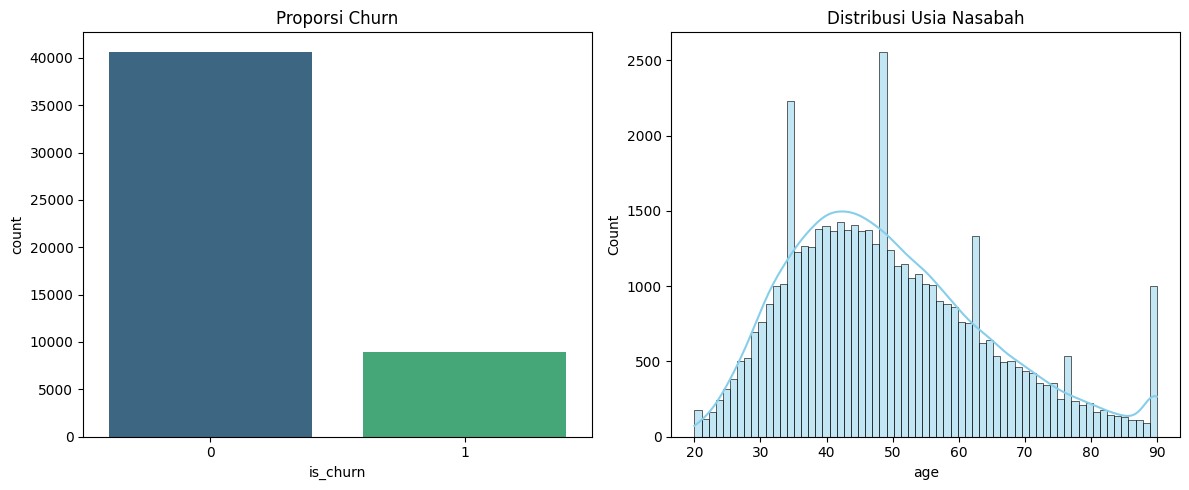

In [8]:
plt.figure(figsize=(12, 5))

# Plot Churn vs stay
plt.subplot(1, 2, 1)
sns.countplot(data=df, x='is_churn', palette='viridis')
plt.title('Proporsi Churn')

# Plot Age Distribution
plt.subplot(1, 2, 2)
sns.histplot(df['age'], kde=True, color='skyblue')
plt.title('Distribusi Usia Nasabah')

plt.tight_layout()
plt.show()

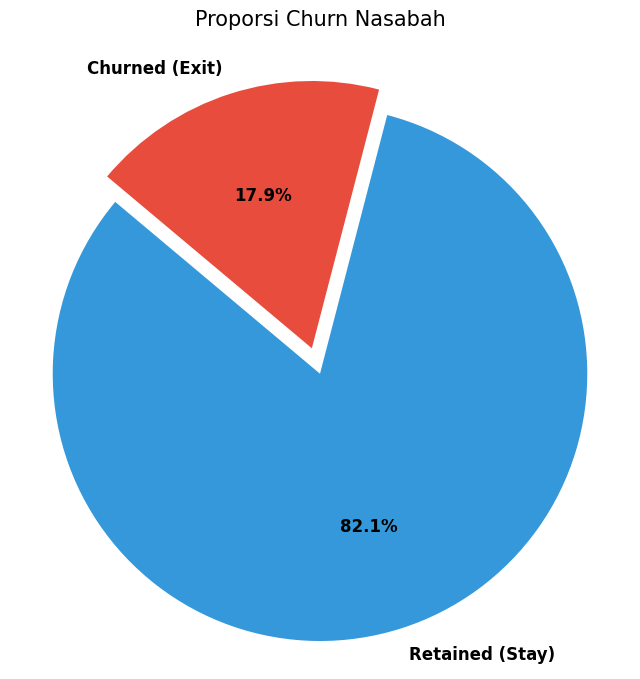

Jumlah Nasabah Bertahan (0): 40677
Jumlah Nasabah Churn (1)   : 8890


In [9]:
churn_counts = df['is_churn'].value_counts()

# Setup Pie Chart
labels = ['Retained (Stay)', 'Churned (Exit)']
sizes = [churn_counts[0], churn_counts[1]]
colors = ['#3498db', '#e74c3c'] 
explode = (0, 0.1)  

# Membuat Plot
plt.figure(figsize=(8, 8))
plt.pie(sizes, 
        explode=explode, 
        labels=labels, 
        colors=colors, 
        autopct='%1.1f%%',
        shadow=False,
        startangle=140,
        textprops={'fontsize': 12, 'fontweight': 'bold'})

plt.title('Proporsi Churn Nasabah', fontsize=15, pad=20)
plt.axis('equal')
plt.show()

# Ringkasan Statistik
print(f"Jumlah Nasabah Bertahan (0): {churn_counts[0]}")
print(f"Jumlah Nasabah Churn (1)   : {churn_counts[1]}")

### Bivariate Analysis

#### Analisis Recency

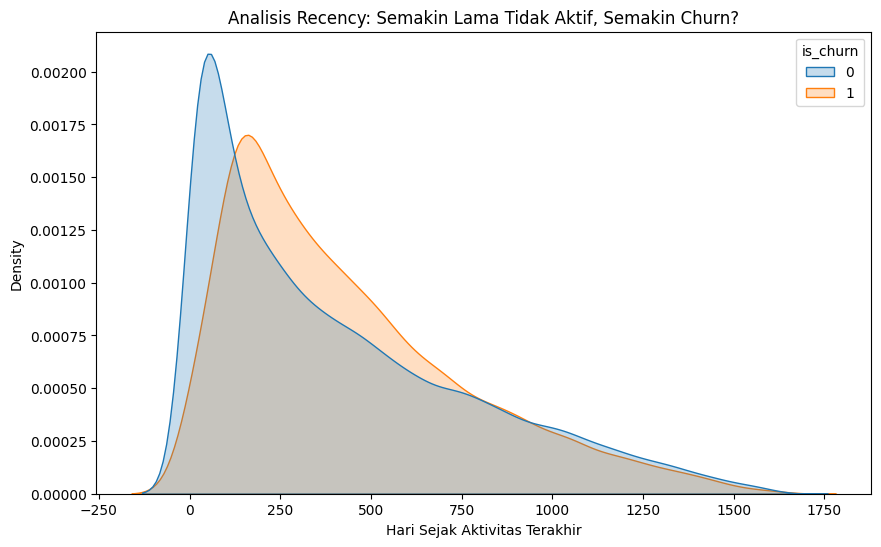

In [10]:
plt.figure(figsize=(10, 6))
sns.kdeplot(data=df, x='recency_days', hue='is_churn', fill=True, common_norm=False)
plt.title('Analisis Recency: Semakin Lama Tidak Aktif, Semakin Churn?')
plt.xlabel('Hari Sejak Aktivitas Terakhir')
plt.show()

#### Binned Churn Rate

C:\Users\HP\AppData\Local\Temp\ipykernel_17332\2366099736.py:6: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  ratio_impact = df.groupby('ratio_bin')['is_churn'].mean() * 100


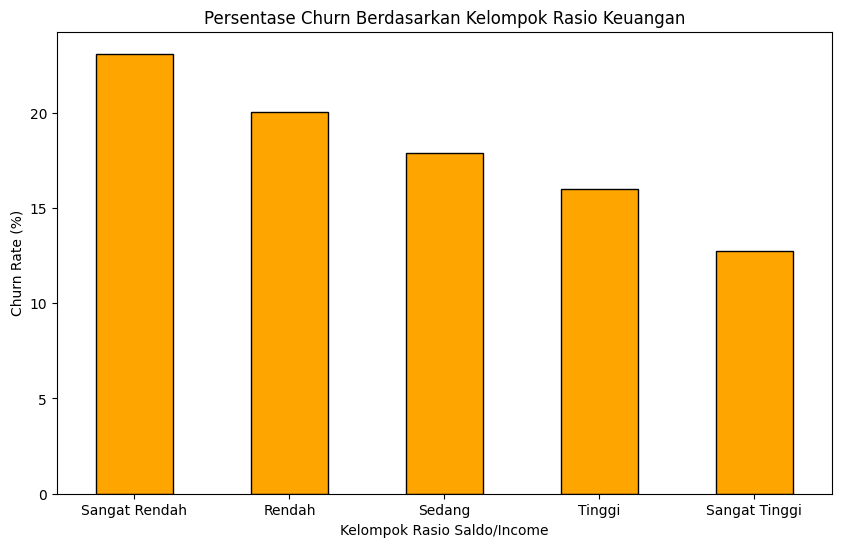

In [11]:
# Membuat kategori rasio
df['ratio_bin'] = pd.qcut(df['balance_income_ratio'], q=5, labels=['Sangat Rendah', 'Rendah', 'Sedang', 'Tinggi', 'Sangat Tinggi'])

plt.figure(figsize=(10, 6))
# Menghitung % churn per kategori
ratio_impact = df.groupby('ratio_bin')['is_churn'].mean() * 100
ratio_impact.plot(kind='bar', color='orange', edgecolor='black')

plt.title('Persentase Churn Berdasarkan Kelompok Rasio Keuangan')
plt.ylabel('Churn Rate (%)')
plt.xlabel('Kelompok Rasio Saldo/Income')
plt.xticks(rotation=0)
plt.show()

#### Churn vs Occupation

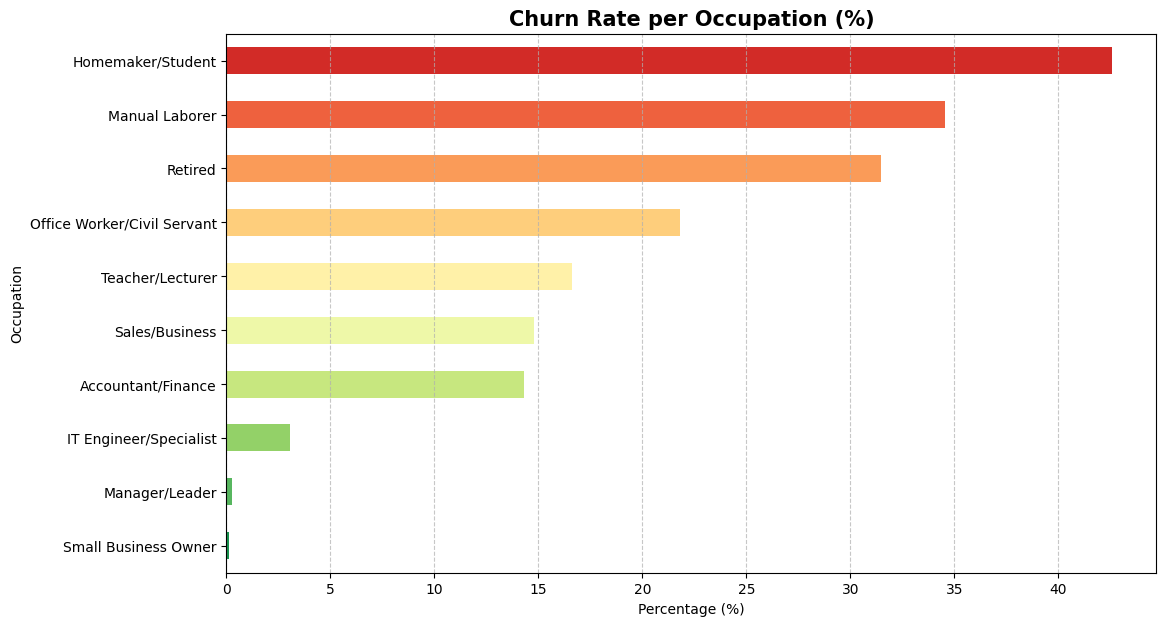

In [12]:
plt.figure(figsize=(12, 7))
# Menghitung % churn di setiap pekerjaan
churn_by_job = df.groupby('occupation')['is_churn'].mean().sort_values() * 100

# Plot dengan warna gradasi
colors = sns.color_palette("RdYlGn_r", len(churn_by_job))
churn_by_job.plot(kind='barh', color=colors)

plt.title('Churn Rate per Occupation (%)', fontsize=15, fontweight='bold')
plt.xlabel('Percentage (%)')
plt.ylabel('Occupation')
plt.grid(axis='x', linestyle='--', alpha=0.7)
plt.show()

#### Multivariate Analysis

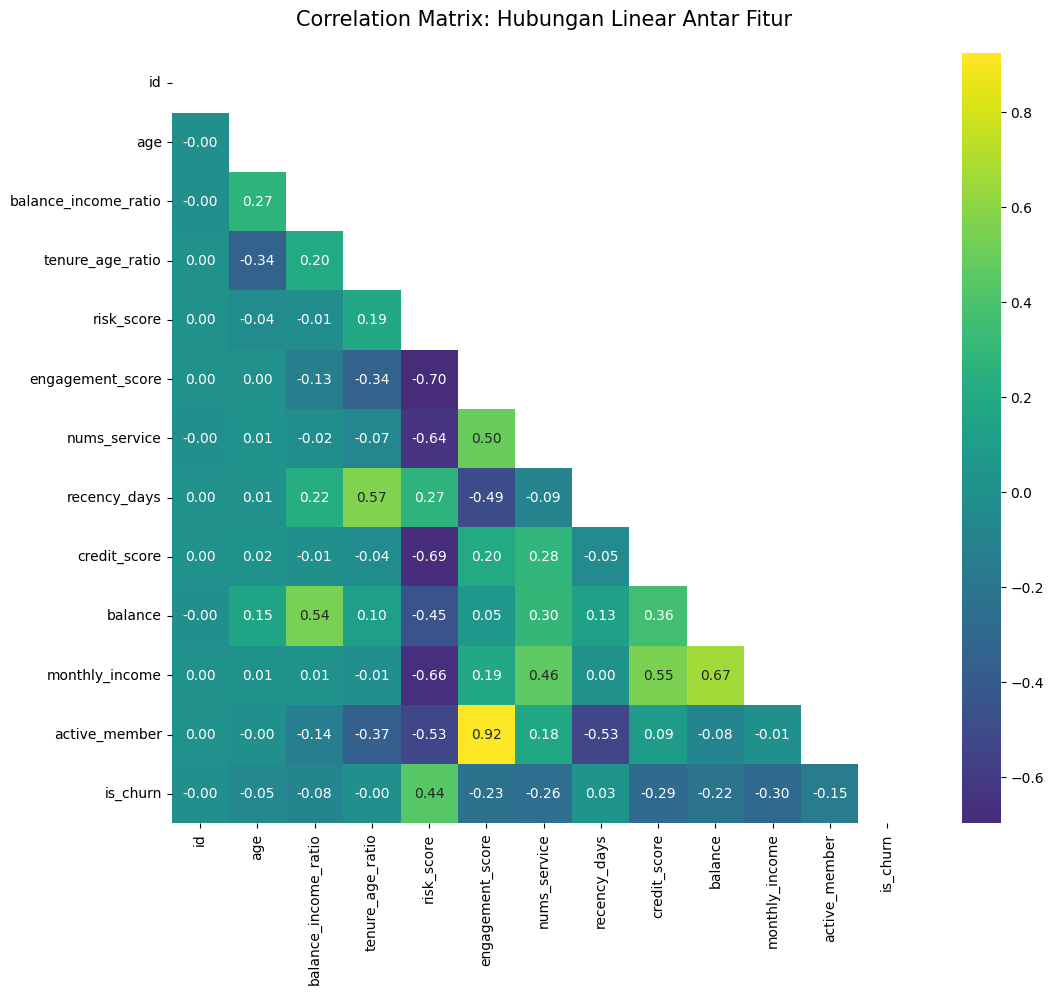

In [13]:
# Memilih hanya kolom numerik untuk korelasi
numeric_df = df.select_dtypes(include=[np.number])

plt.figure(figsize=(12, 10))

# Membuat mask untuk menyembunyikan bagian atas (agar tidak double/redundant)
mask = np.triu(np.ones_like(numeric_df.corr(), dtype=bool))

# Plot Heatmap
sns.heatmap(numeric_df.corr(), mask=mask, annot=True, fmt=".2f", cmap='viridis', center=0)
plt.title('Correlation Matrix: Hubungan Linear Antar Fitur', fontsize=15, pad=20)
plt.show()

In [14]:
df.head(5)

,id,age,gender,occupation,customer_segment,loyalty_level,balance_income_ratio,tenure_age_ratio,risk_score,risk_segment,engagement_score,nums_service,digital_behavior,recency_days,credit_score,balance,monthly_income,active_member,is_churn,ratio_bin
0,1,55,male,Small Business Owner,Priority,Bronze,1.4653,0.0000,0.0359,Low,90.0,8,mobile,90,725,177306004.0,121000000.0,1,0,Sedang
1,2,45,male,Homemaker/Student,Mass,Gold,0.3855,0.0667,0.2664,Low,63.0,2,mobile,49,689,1927416.0,5000000.0,1,0,Sangat Rendah
2,3,44,female,Small Business Owner,Priority,Silver,2.7975,0.0909,0.1343,Low,36.0,8,offline,1391,702,304931745.0,109000000.0,0,0,Sangat Tinggi
3,4,44,male,Small Business Owner,Priority,Bronze,0.6407,0.0682,0.2185,Low,23.0,3,offline,120,766,50615501.0,79000000.0,0,0,Sangat Rendah
4,5,77,female,Teacher/Lecturer,Emerging,Bronze,1.6213,0.0260,0.2942,Low,23.0,3,offline,1061,677,40532432.0,25000000.0,0,0,Tinggi


#### Digital Behavior

In [15]:
print("Kategori Digital Behavior:")
print(df['digital_behavior'].value_counts())

Kategori Digital Behavior:
digital_behavior
offline    39021
mobile     10546
Name: count, dtype: int64


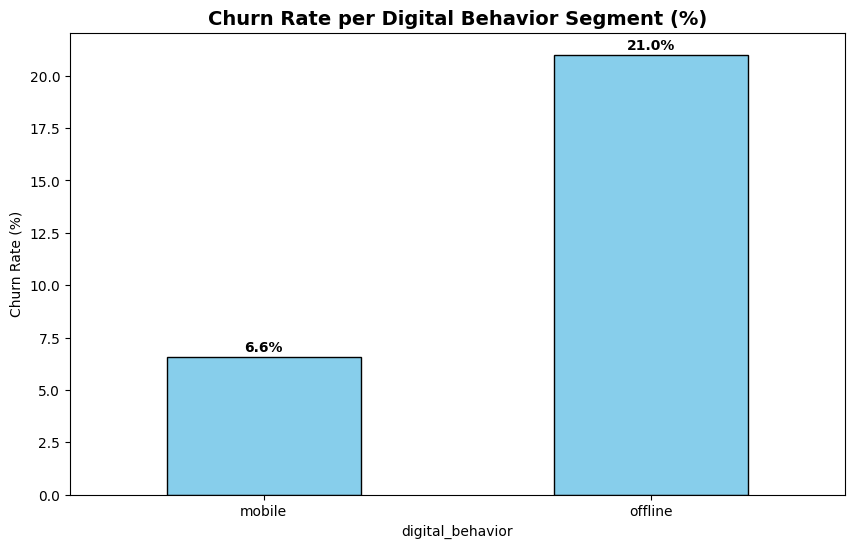

In [16]:
plt.figure(figsize=(10, 6))
# Menghitung persentase churn 
db_churn = df.groupby('digital_behavior')['is_churn'].mean().sort_values() * 100

ax = db_churn.plot(kind='bar', color='skyblue', edgecolor='black')
plt.title('Churn Rate per Digital Behavior Segment (%)', fontsize=14, fontweight='bold')
plt.ylabel('Churn Rate (%)')
plt.xticks(rotation=0)

for p in ax.patches:
    ax.annotate(f'{p.get_height():.1f}%', (p.get_x() + p.get_width() / 2., p.get_height()),
                ha='center', va='center', xytext=(0, 7), textcoords='offset points', fontweight='bold')
plt.show()

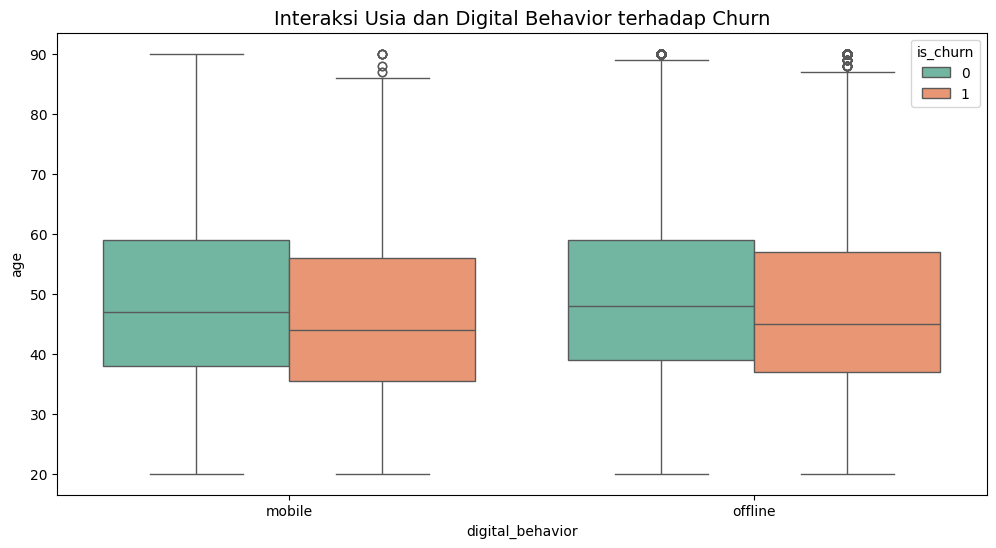

In [17]:
plt.figure(figsize=(12, 6))
sns.boxplot(data=df, x='digital_behavior', y='age', hue='is_churn', palette='Set2')
plt.title('Interaksi Usia dan Digital Behavior terhadap Churn', fontsize=14)
plt.show()

# Feature Engineering

In [18]:
# Age Binning
bins = [0, 25, 45, 62,100]
labels = ['Gen Z', 'Millennial', 'Gen X', 'Baby Boomer']
df['age_group'] = pd.cut(df['age'], bins=bins, labels=labels)

# Financial Health Score
df['financial_stability_index'] = (df['balance_income_ratio'] * df['risk_score']) / 100
print("Fitur Baru Berhasil Dibuat!")

Fitur Baru Berhasil Dibuat!


#### One Hot & Label Encoding

In [19]:
# Mapping Ordinal
loyalty_map = {'Bronze': 1, 'Silver': 2, 'Gold': 3, 'Platinum': 4}
risk_map = {'Low': 1, 'Medium': 2, 'High': 3}

df['loyalty_level'] = df['loyalty_level'].map(loyalty_map)
df['risk_segment'] = df['risk_segment'].map(risk_map)

# Validasi 
if df[['loyalty_level', 'risk_segment']].isnull().sum().sum() > 0:
    raise ValueError("Ada kategori yang tidak ter-mapping")
    
print("Mapping aman, tidak ada kategori liar.")

Mapping aman, tidak ada kategori liar.


In [20]:
# Ambil semua kolom kategori (object)
categorical_cols = df.select_dtypes(include=['object']).columns.tolist()

# Hapus kolom ordinal yang sudah kita mapping
ordinal_cols = ['loyalty_level', 'risk_segment']
nominal_cols = [col for col in categorical_cols if col not in ordinal_cols]

# One Hot Encoding
df_ml = pd.get_dummies(df, columns=nominal_cols, drop_first=True, dtype=int)

print(f"Encoding selesai untuk {len(nominal_cols)} kolom nominal.")

Encoding selesai untuk 4 kolom nominal.


In [21]:
df_ml.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 49567 entries, 0 to 49566
Data columns (total 32 columns):
 #   Column                                  Non-Null Count  Dtype   
---  ------                                  --------------  -----   
 0   id                                      49567 non-null  int64   
 1   age                                     49567 non-null  int64   
 2   loyalty_level                           49567 non-null  int64   
 3   balance_income_ratio                    49567 non-null  float64 
 4   tenure_age_ratio                        49567 non-null  float64 
 5   risk_score                              49567 non-null  float64 
 6   risk_segment                            49567 non-null  int64   
 7   engagement_score                        49567 non-null  float64 
 8   nums_service                            49567 non-null  int64   
 9   recency_days                            49567 non-null  int64   
 10  credit_score                            49567 

#### Scaling

In [22]:
X = df_ml.drop(columns=['id', 'is_churn'])
X = X.select_dtypes(exclude=['object', 'category'])
y = df_ml['is_churn']

In [23]:
scaler = StandardScaler()
try:
    X_scaled = scaler.fit_transform(X)
    print("Data berhasil di-scaling.")
    print(f"Sekarang kamu punya {X_scaled.shape[1]} fitur yang siap.")
except ValueError as e:
    print(f"Masih ada belum di-scaling: {e}")

Data berhasil di-scaling.
Sekarang kamu punya 28 fitur yang siap.


# Modeling

In [24]:
from sklearn.model_selection import train_test_split, StratifiedKFold, cross_val_score

# Split data untuk validasi
X_train, X_test, y_train, y_test = train_test_split(
    X_scaled, y, 
    test_size=0.2, 
    random_state=42, 
    stratify=y
)

# Inisialisasi stratified k-fold
skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

print(f"Data Latihan (K-Fold): {X_train.shape[0]} baris")
print(f"Data Test (Hold-out): {X_test.shape[0]} baris")

Data Latihan (K-Fold): 39653 baris
Data Test (Hold-out): 9914 baris


In [25]:
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier

# Model 1 : Random Forest
rf_model = RandomForestClassifier(n_estimators=100, class_weight='balanced', random_state=42)
rf_model.fit(X_train, y_train)

# Model 2 : XGBoost
ratio = float(y_train.value_counts()[0] / y_train.value_counts()[1])
xgb_model = XGBClassifier(n_estimators=100, 
                          scale_pos_weight=ratio, # Menangani imbalance dengan memberikan bobot pada kelas minoritas  
                          eval_metric='logloss', 
                          random_state=42)
xgb_model.fit(X_train, y_train)


,objective,'binary:logistic'
,use_label_encoder,None
,base_score,None
,booster,None
,callbacks,None
,colsample_bylevel,None
,colsample_bynode,None
,colsample_bytree,None
,early_stopping_rounds,None
,enable_categorical,False
,eval_metric,'logloss'


#### Tuning XGBoost

In [26]:
from sklearn.model_selection import GridSearchCV

xgb_param_grid = {
    'max_depth': [3, 6, 9],
    'learning_rate': [0.01, 0.1, 0.2],
    'n_estimators': [100, 200]
}

xgb_grid_search = GridSearchCV(
    estimator=xgb_model, 
    param_grid=xgb_param_grid, 
    cv=skf, 
    scoring='roc_auc', 
    n_jobs=-1,
    verbose=1
)

xgb_grid_search.fit(X_train, y_train)
xgb_best_model = xgb_grid_search.best_estimator_
print(f"Best XGB Parameters: {xgb_grid_search.best_params_}")


Fitting 5 folds for each of 18 candidates, totalling 90 fits


c:\Users\HP\AppData\Local\Programs\Python\Python311\Lib\site-packages\sklearn\model_selection\_search.py:1137: UserWarning: One or more of the test scores are non-finite: [nan nan nan nan nan nan nan nan nan nan nan nan nan nan nan nan nan nan]
  warnings.warn(


Best XGB Parameters: {'learning_rate': 0.01, 'max_depth': 3, 'n_estimators': 100}


              precision    recall  f1-score   support

           0       0.96      0.70      0.81      8136
           1       0.38      0.85      0.53      1778

    accuracy                           0.73      9914
   macro avg       0.67      0.77      0.67      9914
weighted avg       0.85      0.73      0.76      9914



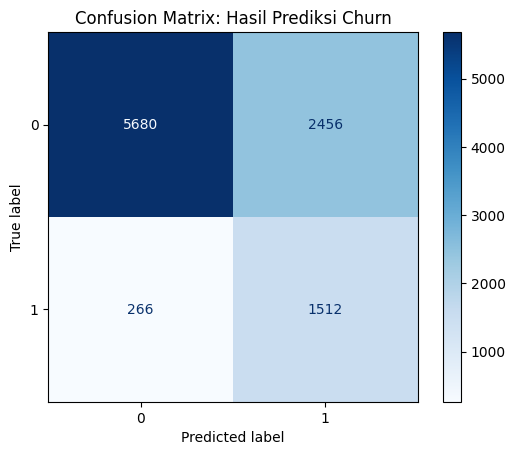

Skor Final ROC-AUC: 0.8522


In [27]:
from sklearn.metrics import confusion_matrix, classification_report, ConfusionMatrixDisplay, roc_auc_score

# Prediksi menggunakan model terbaik (XGBoost Tuned)
y_pred = xgb_best_model.predict(X_test)
print(classification_report(y_test, y_pred))

# Visualisasi Confusion Matrix
cm = confusion_matrix(y_test, y_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=cm)
disp.plot(cmap='Blues')
plt.title('Confusion Matrix: Hasil Prediksi Churn')
plt.show()

# Skor ROC-AUC
auc_score = roc_auc_score(y_test, xgb_best_model.predict_proba(X_test)[:, 1])
print(f"Skor Final ROC-AUC: {auc_score:.4f}")

#### Tuning Random Forest

In [28]:
rf_param_grid = {
    'n_estimators': [100, 200],
    'max_depth': [10, 20, None],
    'min_samples_split': [2, 5],
    'class_weight': ['balanced', 'balanced_subsample']
}

rf_grid_search = GridSearchCV(
    estimator=RandomForestClassifier(random_state=42), 
    param_grid=rf_param_grid, 
    cv=skf, 
    scoring='roc_auc', 
    n_jobs=-1,
    verbose=1
)

rf_grid_search.fit(X_train, y_train)
rf_best_model = rf_grid_search.best_estimator_
print(f"Best RF Parameters: {rf_grid_search.best_params_}")

Fitting 5 folds for each of 24 candidates, totalling 120 fits
Best RF Parameters: {'class_weight': 'balanced_subsample', 'max_depth': 10, 'min_samples_split': 5, 'n_estimators': 200}


              precision    recall  f1-score   support

           0       0.95      0.74      0.83      8136
           1       0.40      0.82      0.54      1778

    accuracy                           0.75      9914
   macro avg       0.68      0.78      0.69      9914
weighted avg       0.85      0.75      0.78      9914



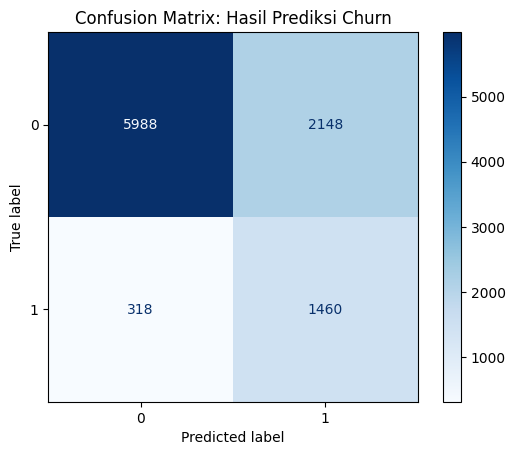

Skor Final ROC-AUC: 0.8555


In [29]:
# Prediksi menggunakan model terbaik (XGBoost Tuned)
y_pred_rf = rf_best_model.predict(X_test)
print(classification_report(y_test, y_pred_rf))

# Visualisasi Confusion Matrix
cm = confusion_matrix(y_test, y_pred_rf)
disp = ConfusionMatrixDisplay(confusion_matrix=cm)
disp.plot(cmap='Blues')
plt.title('Confusion Matrix: Hasil Prediksi Churn')
plt.show()

# Skor ROC-AUC
auc_score = roc_auc_score(y_test, rf_best_model.predict_proba(X_test)[:, 1])
print(f"Skor Final ROC-AUC: {auc_score:.4f}")

In [30]:
# Ambil Prediksi RF Tuned
y_pred_rf = rf_best_model.predict(X_test)
y_prob_rf = rf_best_model.predict_proba(X_test)[:, 1]

# Ambil Prediksi XGBoost Tuned
y_pred_xgb = xgb_best_model.predict(X_test)
y_prob_xgb = xgb_best_model.predict_proba(X_test)[:, 1]

# Ekstrak Metrik untuk Kelas Churn (Label 1)
report_rf = classification_report(y_test, y_pred_rf, output_dict=True)['1']
report_xgb = classification_report(y_test, y_pred_xgb, output_dict=True)['1']

# Buat Tabel Perbandingan Final
final_comparison = {
    'Metric': ['Recall (Churn)', 'Precision (Churn)', 'F1-Score (Churn)', 'ROC-AUC'],
    'Random Forest (Tuned)': [
        report_rf['recall'],
        report_rf['precision'],
        report_rf['f1-score'],
        roc_auc_score(y_test, y_prob_rf)
    ],
    'XGBoost (Tuned)': [
        report_xgb['recall'],
        report_xgb['precision'],
        report_xgb['f1-score'],
        roc_auc_score(y_test, y_prob_xgb)
    ]
}

df_perf = pd.DataFrame(final_comparison)
print("--- TABEL PERBANDINGAN MODEL ---")
print(df_perf.round(4))

--- TABEL PERBANDINGAN MODEL ---
              Metric  Random Forest (Tuned)  XGBoost (Tuned)
0     Recall (Churn)                 0.8211           0.8504
1  Precision (Churn)                 0.4047           0.3810
2   F1-Score (Churn)                 0.5421           0.5263
3            ROC-AUC                 0.8555           0.8522


#### Test Evaluation

<Figure size 800x600 with 0 Axes>

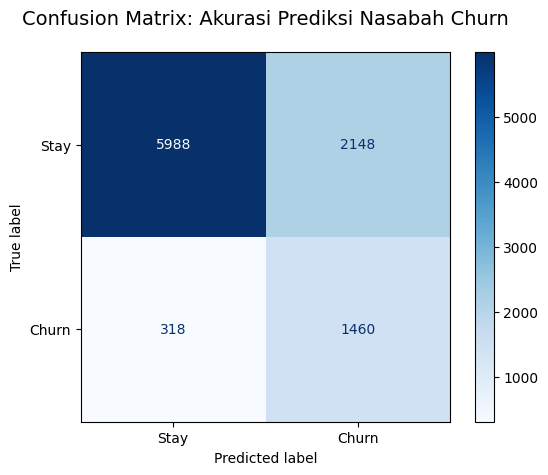

--- STRATIFIED EVALUATION REPORT (RF TUNED) ---
              precision    recall  f1-score   support

        Stay       0.95      0.74      0.83      8136
       Churn       0.40      0.82      0.54      1778

    accuracy                           0.75      9914
   macro avg       0.68      0.78      0.69      9914
weighted avg       0.85      0.75      0.78      9914



In [31]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
# Hitung Matrix
cm = confusion_matrix(y_test, y_pred_rf)

# Visualisasi
plt.figure(figsize=(8, 6))
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['Stay', 'Churn'])
disp.plot(cmap='Blues', values_format='d')

plt.title('Confusion Matrix: Akurasi Prediksi Nasabah Churn', fontsize=14, pad=20)
plt.grid(False) # Menghilangkan garis grid agar rapi
plt.show()

print("--- STRATIFIED EVALUATION REPORT (RF TUNED) ---")
print(classification_report(y_test, y_pred_rf, target_names=['Stay', 'Churn']))

C:\Users\HP\AppData\Local\Temp\ipykernel_17332\1777755116.py:10: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='Importance', y='Feature', data=fi_df, palette='magma')


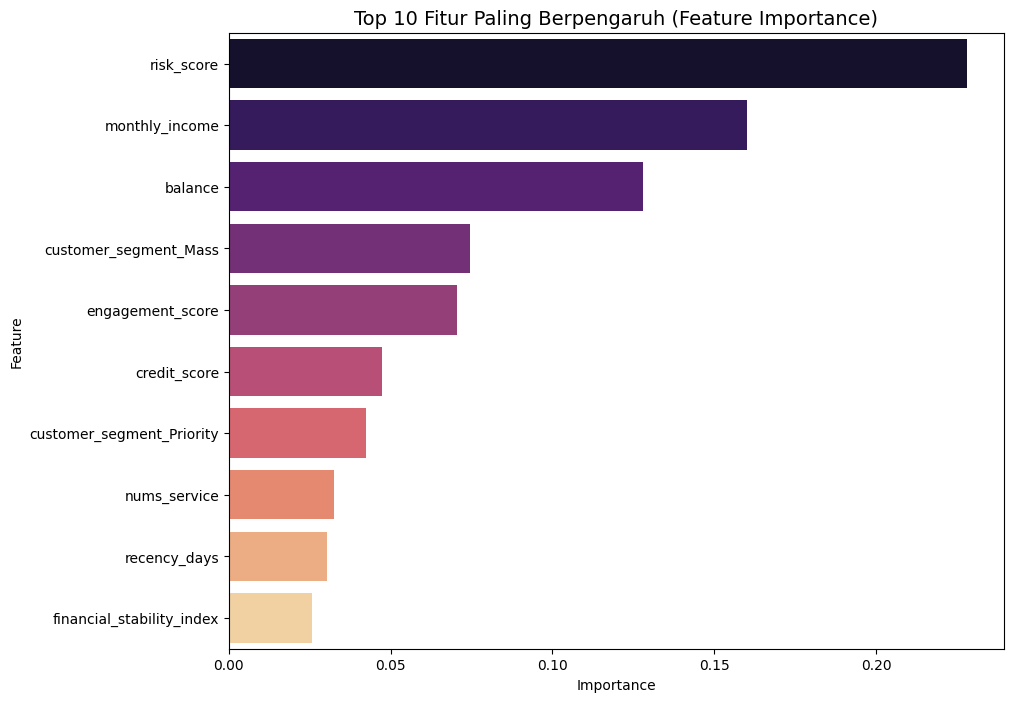

In [32]:
# Ambil Importance Feature Score
importances = rf_best_model.feature_importances_
feature_names = X.columns

# Buat DataFrame
fi_df = pd.DataFrame({'Feature': feature_names, 'Importance': importances})
fi_df = fi_df.sort_values(by='Importance', ascending=False).head(10) # Ambil top 10

plt.figure(figsize=(10, 8))
sns.barplot(x='Importance', y='Feature', data=fi_df, palette='magma')
plt.title('Top 10 Fitur Paling Berpengaruh (Feature Importance)', fontsize=14)
plt.show()

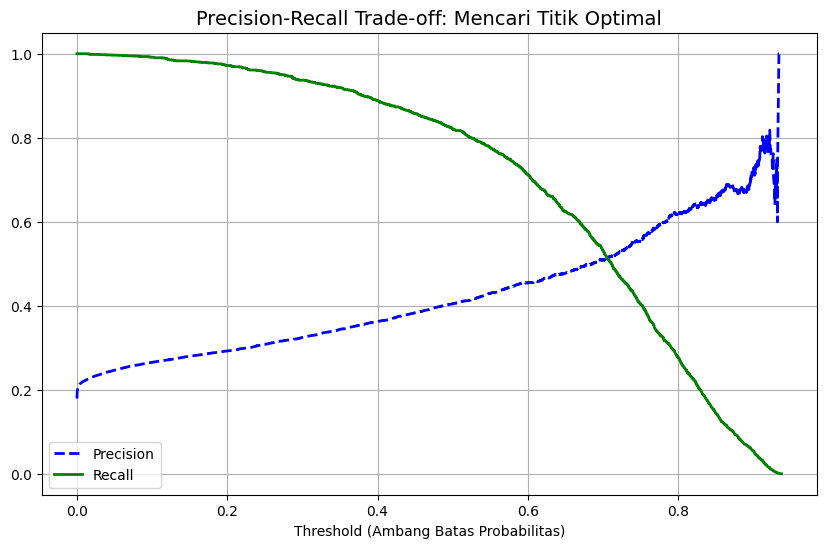

In [33]:
from sklearn.metrics import precision_recall_curve

# 1. Ambil probabilitas (bukan hasil prediksi 0/1)
y_scores = rf_best_model.predict_proba(X_test)[:, 1]

# 2. Hitung precision & recall untuk berbagai threshold
precisions, recalls, thresholds = precision_recall_curve(y_test, y_scores)

# 3. Visualisasi Trade-off
plt.figure(figsize=(10, 6))
plt.plot(thresholds, precisions[:-1], "b--", label="Precision", linewidth=2)
plt.plot(thresholds, recalls[:-1], "g-", label="Recall", linewidth=2)
plt.xlabel("Threshold (Ambang Batas Probabilitas)")
plt.title("Precision-Recall Trade-off: Mencari Titik Optimal", fontsize=14)
plt.legend()
plt.grid(True)
plt.show()

# CONTOH: Menggunakan Threshold baru (misal 0.6)
y_pred_new = (y_scores >= 0.6).astype(int)
# Cek hasilnya, Precision pasti naik!

In [34]:
y_probs = rf_best_model.predict_proba(X_test)[:, 1]

# Tentukan threshold baru
new_threshold = 0.7

# 3. Klasifikasikan: Jika probabilitas >= 0.7 maka 1 (Churn), selain itu 0 (Stay)
y_pred_new = (y_probs >= new_threshold).astype(int)

print(f"Threshold berhasil diubah ke: {new_threshold}")

Threshold berhasil diubah ke: 0.7


In [35]:
from sklearn.metrics import classification_report

# Evaluasi Standar
print("--- EVALUASI DENGAN THRESHOLD 0.5 (DEFAULT) ---")
print(classification_report(y_test, rf_best_model.predict(X_test)))

# Evaluasi Optimal (Hasil Threshold Moving)
print(f"--- EVALUASI DENGAN THRESHOLD {new_threshold} (OPTIMAL) ---")
print(classification_report(y_test, y_pred_new))

--- EVALUASI DENGAN THRESHOLD 0.5 (DEFAULT) ---
              precision    recall  f1-score   support

           0       0.95      0.74      0.83      8136
           1       0.40      0.82      0.54      1778

    accuracy                           0.75      9914
   macro avg       0.68      0.78      0.69      9914
weighted avg       0.85      0.75      0.78      9914

--- EVALUASI DENGAN THRESHOLD 0.7 (OPTIMAL) ---
              precision    recall  f1-score   support

           0       0.90      0.89      0.89      8136
           1       0.51      0.53      0.52      1778

    accuracy                           0.82      9914
   macro avg       0.70      0.71      0.71      9914
weighted avg       0.83      0.82      0.83      9914



In [36]:
# import joblib

# # Simpan Model Random Forest (Tuned)
# joblib.dump(rf_best_model, 'model_rf_churn_final.pkl')

# # Simpan Model XGBoost (Tuned)
# joblib.dump(xgb_best_model, 'model_xgb_churn_final.pkl')
# joblib.dump(scaler, 'scaler_churn.pkl')

# feature_cols = X.columns.tolist()
# joblib.dump(feature_cols, 'feature_columns.pkl')

# print(" Berhasil mengekspor 4 file utama:")
# print("1. model_rf_churn_final.pkl")
# print("2. model_xgb_churn_final.pkl")
# print("3. scaler_churn.pkl")
# print("4. feature_columns.pkl")

In [37]:
df['prediction_churn'] = rf_best_model.predict(X_scaled)
df['churn_probability'] = rf_best_model.predict_proba(X_scaled)[:, 1]

df.to_csv('vietnam_bank_churn_prediction.csv', index=False)